# Retrospectiva post-freeze

Validación fuera de muestra **complementaria** al paper trading live, ejecutada sobre datos posteriores al freeze académico (`2026-02-28`) y bajo las mismas reglas operativas que el live: misma `promotion_manifest.json`, mismos modelos congelados, mismo filtro EVT/CVaR, misma política de sizing. **No** se reentrena ni reoptimiza nada; **no** sustituye al live, lo complementa.

Este notebook lee los `events.jsonl` producidos por `scripts/run_post_freeze_retrospective.py` bajo `reports/paper_trading/retrospective/<run_id>/<symbol>/` y calcula **exactamente** las mismas métricas que el postmortem del live (`03_postmortem_paper_trading.ipynb`), de forma que el bloque Results del TFG pueda presentar paper live y retrospectiva post-freeze lado a lado sin recortes metodológicos.

**Prerrequisitos:** promoción (`01_tabla_promocion.ipynb`), gate de sanidad (`02_comprobacion_sanidad_senales.ipynb`) y postmortem live (`03_postmortem_paper_trading.ipynb`).

Causalidad y ausencia de leakage están garantizadas por construcción en el runner: `endTime=decision_ts` para klines, `end=decision_ts` con `freeze_end_coverage` no estricto en `build_features` y `refresh_live_data_before_decision=False` (no se ejecuta live ingest durante la retrospectiva).

**Productos:** `reports/paper_trading/retrospective/<run_id>/retrospective_postmortem.json`. Las figuras de las secciones 2–4 son exploratorias (`plt.show()`); no se exportan a `reports/figures/` desde este notebook.


In [34]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'src' / 'live' / 'paper_runner.py').exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'src' / 'live' / 'paper_runner.py').exists():
    raise SystemExit('No se encuentra el repo del TFG.')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

LIVE_ROOT = REPO_ROOT / 'reports' / 'paper_trading' / 'live'
RETROSPECTIVE_ROOT = REPO_ROOT / 'reports' / 'paper_trading' / 'retrospective'


def _count_events(run_dir: Path) -> tuple[int, int]:
    symbol_dirs = [p for p in run_dir.iterdir() if p.is_dir() and (p / 'events.jsonl').exists()]
    n_events = 0
    for symbol_dir in symbol_dirs:
        with (symbol_dir / 'events.jsonl').open('r', encoding='utf-8') as fh:
            n_events += sum(1 for line in fh if line.strip())
    return len(symbol_dirs), n_events


def _summarize_runs(root: Path, *, kind: str) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    if root.exists():
        for run_dir in sorted(root.iterdir()):
            if not run_dir.is_dir():
                continue
            n_symbols, n_events = _count_events(run_dir)
            if n_symbols == 0:
                continue
            rows.append({'tipo': kind, 'id_corrida': run_dir.name, 'n_simbolos': n_symbols, 'n_eventos': n_events})
    return pd.DataFrame(rows)


available_runs = pd.concat(
    [
        _summarize_runs(RETROSPECTIVE_ROOT, kind='retrospective'),
        _summarize_runs(LIVE_ROOT, kind='live'),
    ],
    ignore_index=True,
)
if available_runs.empty:
    print('No hay corridas paper_trading persistidas bajo reports/.')
else:
    print('Corridas disponibles (retrospectiva -> este notebook; live -> 03_postmortem_paper_trading.ipynb):')
    display(available_runs.sort_values(['tipo', 'n_eventos'], ascending=[True, False]))

# Corrida canónica post-freeze: vol_target alineado al contrato congelado + cap spot
RUN_ID: str = 'retrospective_postfreeze_20260301_20260430_voltarget_spot_cap'
RUN_ROOT = RETROSPECTIVE_ROOT / RUN_ID

# Comparativa live: replay determinista de la ventana 21-28 may 2026 con el mismo stack
LIVE_RUN_ID: str | None = 'live_window_replay_20260521T0800_20260528T0800_voltarget_spot_cap'
LIVE_RUN_ROOT = (
    RETROSPECTIVE_ROOT / LIVE_RUN_ID if LIVE_RUN_ID else None
)

print(f'RUN_ID={RUN_ID!r} | RUN_ROOT={RUN_ROOT} (exists={RUN_ROOT.exists()})')
print(f'LIVE_RUN_ID={LIVE_RUN_ID!r} | LIVE_RUN_ROOT={LIVE_RUN_ROOT} '
      f'(exists={LIVE_RUN_ROOT.exists() if LIVE_RUN_ROOT else False})')


Corridas disponibles (retrospectiva -> este notebook; live -> 03_postmortem_paper_trading.ipynb):


,tipo,id_corrida,n_simbolos,n_eventos
9,live,paper_live_20260521T1200Z,5,215
8,live,paper_live_20260521,5,24
7,live,paper_dryrun_smoke_20260520,5,6
10,live,paper_live_dryrun_20260521T1200Z,5,5
11,live,paper_smoke_pre7d_20260520,5,5
12,live,paper_smoke_pre7d_20260520_postfix,5,5
13,live,paper_smoke_pre7d_20260520_postfix2,5,5
14,live,paper_smoke_pre7d_20260520_postfix3,5,5
2,retrospective,retrospective_postfreeze_20260301_20260430,5,1830
4,retrospective,retrospective_postfreeze_20260301_20260430_vol...,5,1830


RUN_ID='retrospective_postfreeze_20260301_20260430_voltarget_spot_cap' | RUN_ROOT=/app/reports/paper_trading/retrospective/retrospective_postfreeze_20260301_20260430_voltarget_spot_cap (exists=True)
LIVE_RUN_ID='live_window_replay_20260521T0800_20260528T0800_voltarget_spot_cap' | LIVE_RUN_ROOT=/app/reports/paper_trading/retrospective/live_window_replay_20260521T0800_20260528T0800_voltarget_spot_cap (exists=True)


In [35]:
def load_events(symbol_dir: Path) -> pd.DataFrame:
    events_path = symbol_dir / 'events.jsonl'
    rows = []
    with events_path.open('r', encoding='utf-8') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    df = pd.DataFrame(rows)
    if 'decision_ts' in df.columns:
        df['decision_ts'] = pd.to_datetime(df['decision_ts'], utc=True)
        df = df.set_index('decision_ts').sort_index()
    return df

if not RUN_ROOT.exists():
    print(f'RUN_ROOT no existe: {RUN_ROOT}. Revisa RUN_ID en la celda anterior.')
    symbol_dirs: list[Path] = []
else:
    symbol_dirs = sorted([p for p in RUN_ROOT.iterdir() if p.is_dir() and (p / 'events.jsonl').exists()])
    if not symbol_dirs:
        print(f'RUN_ROOT existe pero no contiene subdirectorios con events.jsonl: {RUN_ROOT}')

events_by_symbol = {p.name: load_events(p) for p in symbol_dirs}
if events_by_symbol:
    print('Eventos por símbolo:', {k: len(v) for k, v in events_by_symbol.items()})
else:
    print('Sin events.jsonl cargados.')


Eventos por símbolo: {'BNBUSDT': 366, 'BTCUSDT': 366, 'ETHUSDT': 366, 'SOLUSDT': 366, 'XRPUSDT': 366}


## 1. Métricas por símbolo (mismo formato que el live)

Calculamos a partir de la JSONL **un único pase de retornos por barra** (sobre la `equity` ya neta de comisiones; ver `transaction_cost_bps` en el `run_manifest.json` de cada símbolo) y derivamos:

- `sharpe_paper_anual_4h`: media/std de retornos por barra, anualizado a 6 x 365 barras 4h.
- `sortino_paper_anual_4h`: variante con std solo de retornos negativos.
- `drawdown_max_paper`: drawdown máximo de la curva de equity.
- `indice_ulcer_paper`: raíz cuadrática media de los drawdowns relativos (Martin & McCann, 1989); penaliza la **profundidad y duración** de las caídas, complementando al drawdown máximo.
- `tasa_aciertos`, `pct_largo` / `pct_corto` / `pct_plano`, `pct_bloqueo_riesgo`, `pct_feature_degradada`.

Las fórmulas son **idénticas** a las usadas en `03_postmortem_paper_trading.ipynb`.


In [36]:
BARS_PER_YEAR_4H = 6 * 365  # 4h grid UTC: 6 barras / día x 365 días

def equity_series(df: pd.DataFrame) -> pd.Series:
    return df['portfolio'].apply(
        lambda d: float(d.get('equity')) if isinstance(d, dict) and d.get('equity') is not None else float('nan')
    ).dropna()

def per_bar_returns(df: pd.DataFrame) -> pd.Series:
    return equity_series(df).pct_change().dropna()

def drawdown_series(equity: pd.Series) -> pd.Series:
    if equity.empty:
        return pd.Series(dtype=float)
    peak = equity.cummax()
    return (equity - peak) / peak

def ulcer_index(equity: pd.Series) -> float:
    """Ulcer Index sobre drawdowns porcentuales (Martin & McCann, 1989)."""
    dd = drawdown_series(equity)
    if dd.empty:
        return float('nan')
    return float(np.sqrt(np.mean(np.square(dd.values))))

def metrics_for(df: pd.DataFrame) -> dict:
    if df.empty:
        return {'n_eventos': 0}
    rets = per_bar_returns(df)
    blocked = df['risk'].apply(lambda d: bool(d.get('blocked')) if isinstance(d, dict) else False)
    feat_complete = df['feature_complete'].astype(bool) if 'feature_complete' in df.columns else pd.Series([True]*len(df))
    std_full = rets.std(ddof=1) if not rets.empty else float('nan')
    realised_sharpe = (
        float(rets.mean() / std_full * np.sqrt(BARS_PER_YEAR_4H))
        if std_full and std_full > 0 else float('nan')
    )
    downside = rets[rets < 0]
    std_down = downside.std(ddof=1) if not downside.empty else float('nan')
    sortino = (
        float(rets.mean() / std_down * np.sqrt(BARS_PER_YEAR_4H))
        if std_down and std_down > 0 else float('nan')
    )
    equity = equity_series(df)
    max_dd = float(drawdown_series(equity).min()) if not equity.empty else float('nan')
    ui = ulcer_index(equity)
    sides = df['signal_side'].astype(int) if 'signal_side' in df.columns else pd.Series([0]*len(df))
    return {
        'n_eventos': int(len(df)),
        'primera_decision_ts': df.index.min().isoformat() if len(df) else None,
        'ultima_decision_ts': df.index.max().isoformat() if len(df) else None,
        'pct_largo': float((sides == 1).mean()),
        'pct_corto': float((sides == -1).mean()),
        'pct_plano': float((sides == 0).mean()),
        'pct_bloqueo_riesgo': float(blocked.mean()) if len(blocked) else 0.0,
        'pct_feature_degradada': float((~feat_complete).mean()),
        'equity_final': float(equity.iloc[-1]) if not equity.empty else float('nan'),
        'retorno_total_pct': float(equity.iloc[-1] / equity.iloc[0] - 1) if len(equity) > 1 else float('nan'),
        'sharpe_paper_anual_4h': realised_sharpe,
        'sortino_paper_anual_4h': sortino,
        'drawdown_max_paper': max_dd,
        'indice_ulcer_paper': ui,
        'tasa_aciertos': float((rets > 0).mean()) if not rets.empty else float('nan'),
    }

def saldo_indice_100(serie: pd.Series) -> pd.Series:
    """Convierte el saldo en índice: primer día = 100 (fácil de comparar en %)."""
    if serie.empty:
        return serie
    base = float(serie.iloc[0])
    if base == 0.0:
        return serie * float('nan')
    return serie / base * 100.0


In [37]:
metrics = pd.DataFrame(
    {sym: metrics_for(df) for sym, df in events_by_symbol.items()}
).T
metrics.index.name = 'simbolo'
metrics


,n_eventos,primera_decision_ts,ultima_decision_ts,pct_largo,pct_corto,pct_plano,pct_bloqueo_riesgo,pct_feature_degradada,equity_final,retorno_total_pct,sharpe_paper_anual_4h,sortino_paper_anual_4h,drawdown_max_paper,indice_ulcer_paper,tasa_aciertos
simbolo,,,,,,,,,,,,,,,
BNBUSDT,366,2026-03-01T00:00:00+00:00,2026-04-30T20:00:00+00:00,0.644809,0.355191,0.0,0.0,0.0,9793.98546,-0.020541,-5.389923,-6.702996,-0.02156,0.013754,0.452055
BTCUSDT,366,2026-03-01T00:00:00+00:00,2026-04-30T20:00:00+00:00,1.0,0.0,0.0,0.0,0.0,11398.11764,0.140953,2.067161,3.440715,-0.118499,0.058679,0.49589
ETHUSDT,366,2026-03-01T00:00:00+00:00,2026-04-30T20:00:00+00:00,0.068306,0.931694,0.0,0.0,0.0,9222.07165,-0.077612,-3.686494,-4.826919,-0.093517,0.05245,0.457534
SOLUSDT,366,2026-03-01T00:00:00+00:00,2026-04-30T20:00:00+00:00,0.661202,0.338798,0.0,0.0,0.0,9947.26341,-0.005265,-6.211325,-7.777381,-0.00535,0.003705,0.471233
XRPUSDT,366,2026-03-01T00:00:00+00:00,2026-04-30T20:00:00+00:00,0.286885,0.713115,0.0,0.0,0.0,10000.706287,0.000071,3.238956,4.495783,-0.000041,0.000015,0.49863


## 2. Trayectoria de equity del paper (retrospectiva)

**Pregunta:** ¿cómo evolucionó el saldo de la cuenta simulada barra a barra sobre la ventana post-freeze?

Cada punto es `portfolio.equity` en el JSONL: efectivo + posición valorada al `close_price` de la vela 4h, **después de comisiones**. No es el precio del activo ni la señal del modelo; es el dinero total que el runner atribuye a la cartera en ese instante.

El gráfico usa un **índice con base 100** en la primera barra (solo escala de lectura: 101 equivale a +1 %, 94 a -6 %). La línea gris punteada marca el nivel inicial.


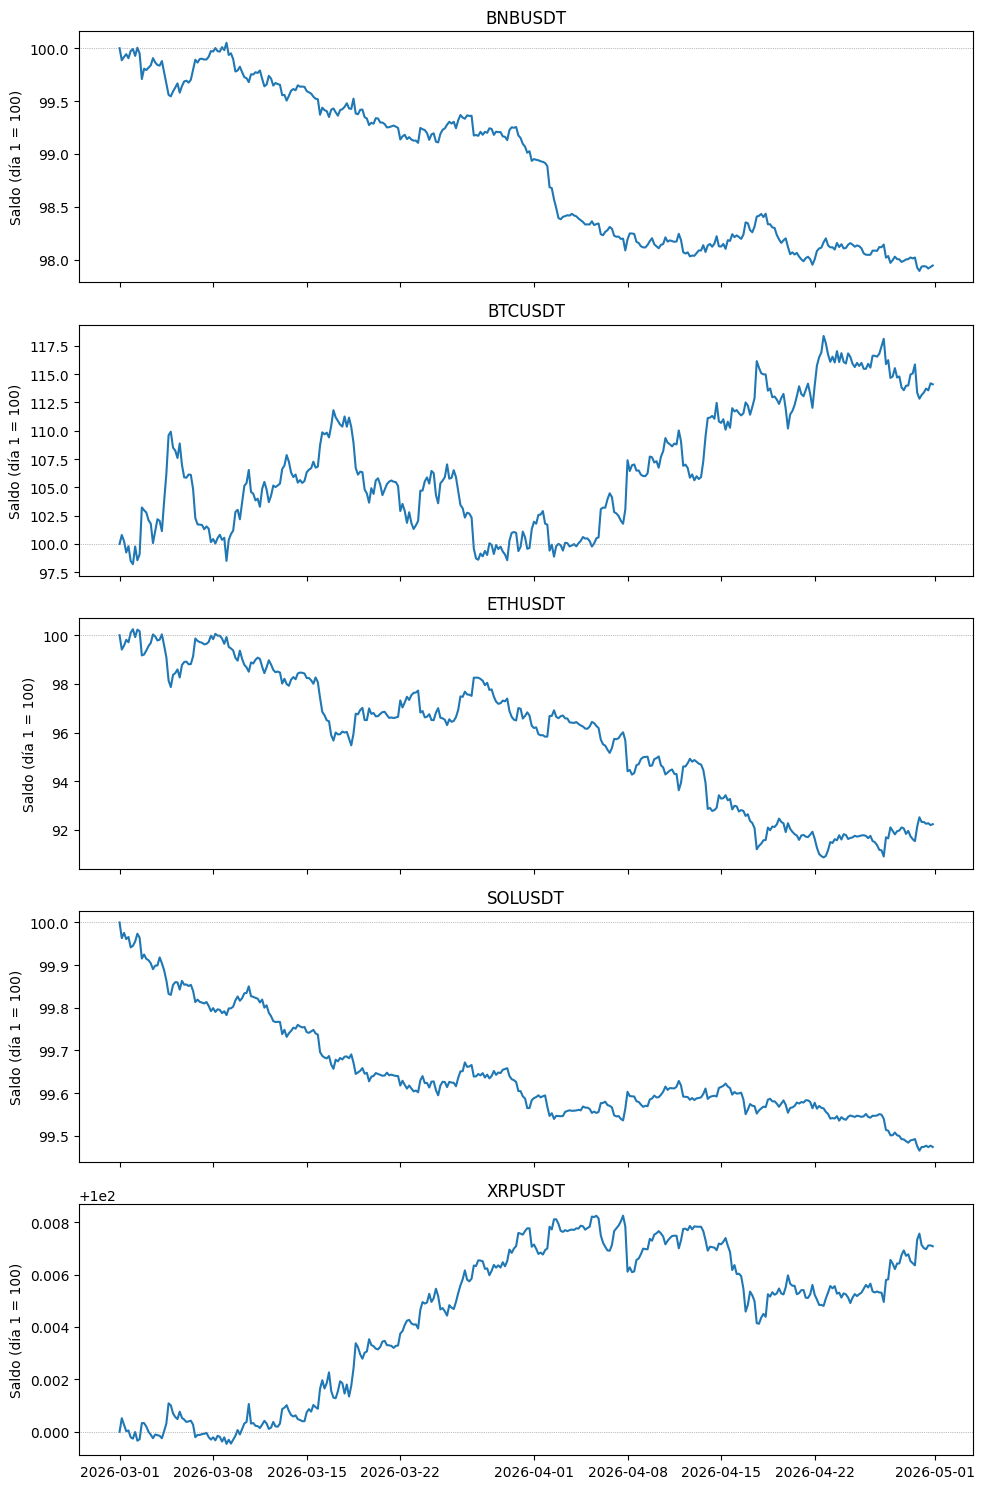

In [38]:
import matplotlib.pyplot as plt

if not events_by_symbol:
    print(
        f'Sin datos para graficar: no hay subdirectorios con events.jsonl bajo {RUN_ROOT}. '
        f'Comprueba RUN_ID (actual: {RUN_ID!r}) y que la retrospectiva haya finalizado.'
    )
else:
    nrows = len(events_by_symbol)
    fig, axes = plt.subplots(nrows, 1, figsize=(10, 3 * nrows), sharex=True)
    if nrows == 1:
        axes = [axes]
    for ax, (sym, df) in zip(axes, events_by_symbol.items()):
        if df.empty:
            ax.set_title(f'{sym} (sin eventos)')
            continue
        saldo = equity_series(df)
        if saldo.empty:
            ax.set_title(f'{sym} (sin saldo registrado)')
            continue
        idx = saldo_indice_100(saldo)
        ax.plot(idx.index, idx.values, label='Tu bot (retrospectiva)')
        ax.axhline(100.0, color='gray', lw=0.5, ls=':')
        ax.set_title(sym)
        ax.set_ylabel('Saldo (día 1 = 100)')
    plt.tight_layout()
    plt.show()


## 3. Precio, señal del modelo, flips y evolución de exposición

**Pregunta:** ¿qué hizo el modelo en el mercado a lo largo de la ventana post-freeze y cuándo cambió de lado o de tamaño?

Este bloque es **operativo**, no de PnL acumulado:

- **Todos los símbolos:** panel de **precio de cierre** (`close_price` en el JSONL) y **flips** (cambio de signo de `portfolio.position`: largo / corto / flat). Los marcadores no cuentan rebalanceos que mantienen la misma dirección.
- **Solo `vol_target` (BTC y XRP en el manifiesto congelado):** panel adicional con **exposición neta en % del saldo** y rebalanceos (+ más exposición, × menos exposición). En `fixed_control` (BNB, ETH, SOL) ese segundo panel no aporta.

**Lectura visual**

- Fondo: verde = señal larga, rojo = corta, gris = flat (`signal_side` del modelo).
- Flips en el panel de precio: triángulo arriba = paso a largo, abajo = corto, círculo = flat.
- En BTC/XRP, línea ámbar vertical = rebalanceo de tamaño sin flip de dirección.

Complementa la sección 2 (saldo) y la 4 (benchmark de rentabilidad).


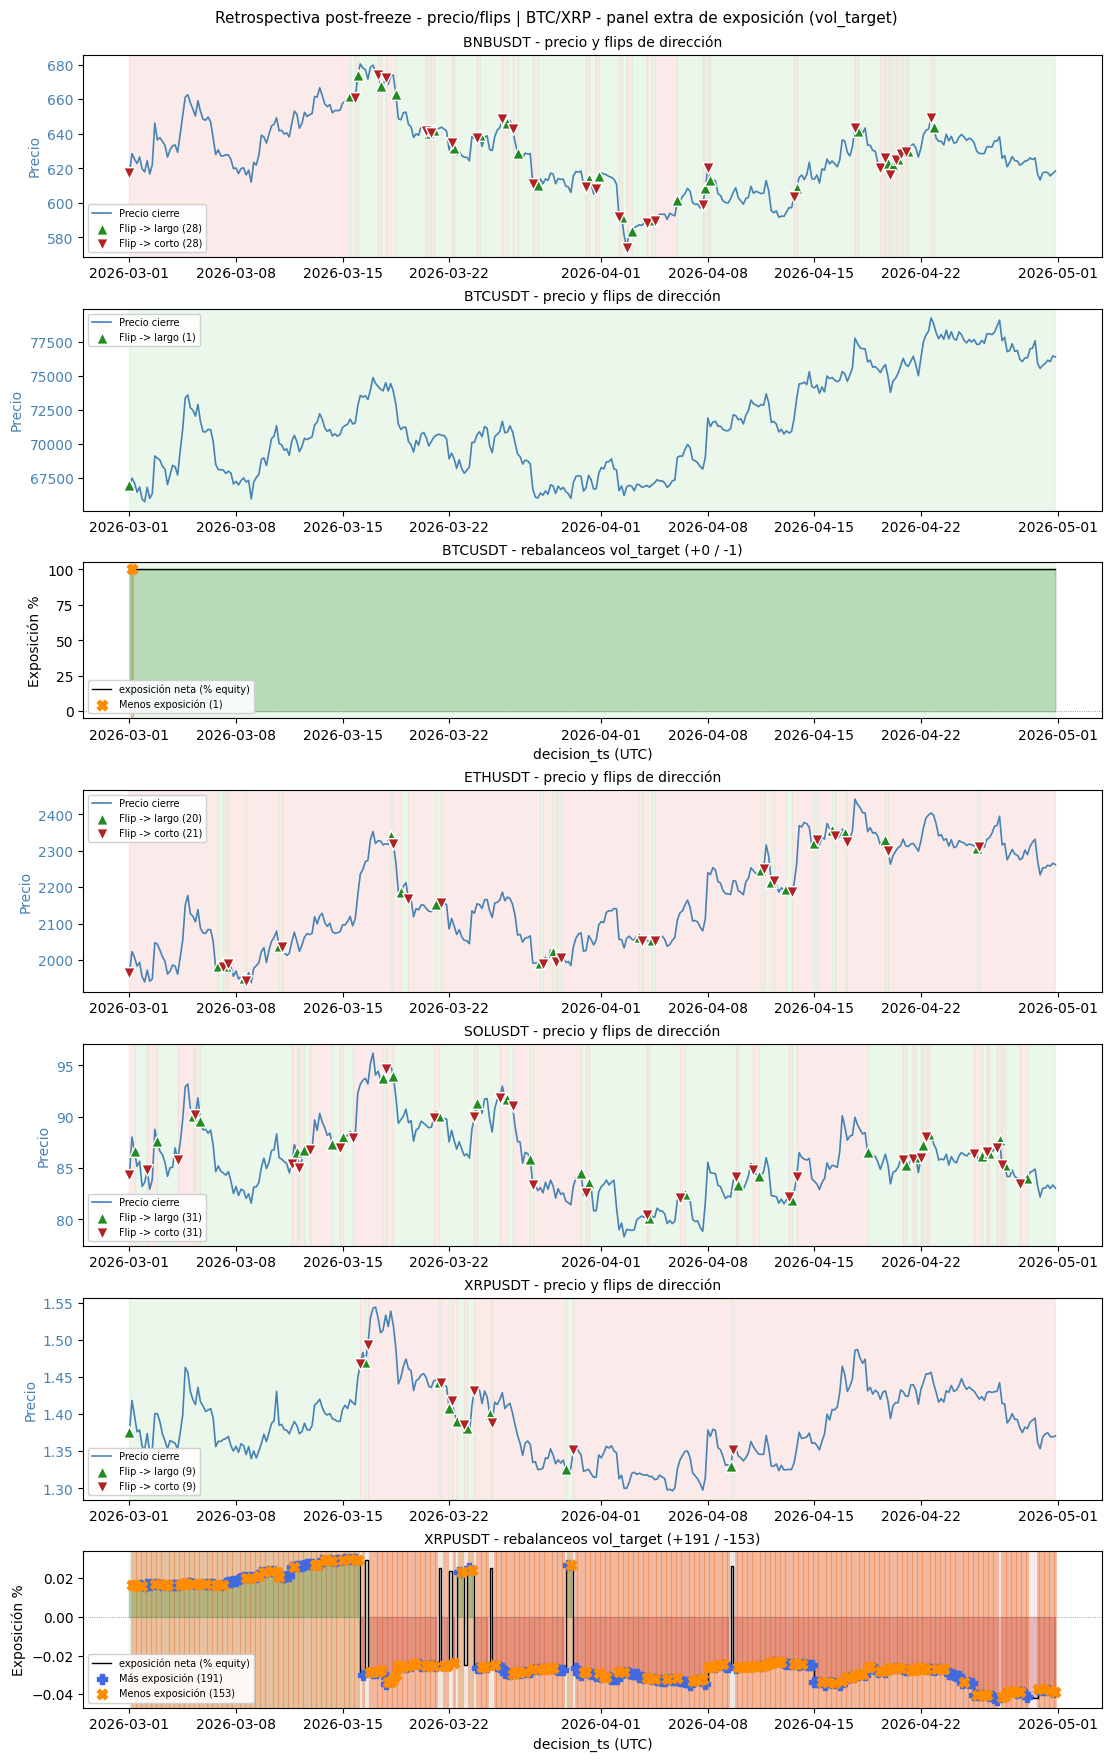

In [39]:
if not events_by_symbol:
    print(
        f'Sin datos para graficar precio/posición: no hay subdirectorios en {RUN_ROOT}'
    )
else:
    import matplotlib.pyplot as plt

    TRADE_EPS = 1e-6

    def _portfolio_position(frame: pd.DataFrame) -> pd.Series:
        if 'portfolio' in frame.columns:
            def _pos(blob: object) -> float:
                if isinstance(blob, dict):
                    return float(blob.get('position') or 0.0)
                return 0.0
            return frame['portfolio'].map(_pos)
        if 'target_position_size' in frame.columns:
            return pd.to_numeric(
                frame['target_position_size'], errors='coerce'
            ).fillna(0.0)
        return pd.Series(0.0, index=frame.index)

    def _portfolio_equity(frame: pd.DataFrame) -> pd.Series:
        if 'portfolio' in frame.columns:
            def _eq(blob: object) -> float:
                if isinstance(blob, dict):
                    return float(blob.get('equity') or float('nan'))
                return float('nan')
            return frame['portfolio'].map(_eq)
        return pd.Series(float('nan'), index=frame.index)

    def _sign_position(pos: pd.Series, *, eps: float = 1e-8) -> pd.Series:
        return pos.apply(
            lambda x: 0 if abs(x) < eps else (1 if x > 0 else -1)
        ).astype(int)

    def _shade_signal_side(ax, ts: pd.Index, sides: pd.Series) -> None:
        palette = {1: '#d9f2d9', -1: '#f9d9d9', 0: '#f2f2f2'}
        if len(ts) == 0:
            return
        seg_side = int(sides.iloc[0]) if len(sides) else 0
        seg_start = ts[0]
        for i in range(1, len(ts)):
            side_i = int(sides.iloc[i])
            if side_i == seg_side:
                continue
            ax.axvspan(
                seg_start, ts[i], color=palette.get(seg_side, '#f2f2f2'),
                alpha=0.55, zorder=0,
            )
            seg_side, seg_start = side_i, ts[i]
        ax.axvspan(
            seg_start, ts[-1], color=palette.get(seg_side, '#f2f2f2'),
            alpha=0.55, zorder=0,
        )

    def _sizing_policy_name(frame: pd.DataFrame) -> str:
        if frame.empty:
            return ''
        sizing = frame.iloc[0].get('sizing') or {}
        return str(sizing.get('policy_name') or sizing.get('policy') or '')

    def _prepare_frame(df: pd.DataFrame) -> dict:
        ts = df.index
        prices = pd.to_numeric(df['close_price'], errors='coerce')
        sides = (
            df['signal_side'].astype(int)
            if 'signal_side' in df.columns
            else pd.Series(0, index=ts, dtype=int)
        )
        exec_delta = (
            pd.to_numeric(df['executed_delta'], errors='coerce').fillna(0.0)
            if 'executed_delta' in df.columns
            else pd.Series(0.0, index=ts)
        )
        held_pos = _portfolio_position(df)
        equity = _portfolio_equity(df)
        held_sign = _sign_position(held_pos)
        prev_sign = held_sign.shift(1).fillna(0).astype(int)
        prev_pos = held_pos.shift(1).fillna(0.0)
        sign_changed = held_sign != prev_sign
        notional = (held_pos * prices).abs()
        with np.errstate(divide='ignore', invalid='ignore'):
            expos_pct = np.where(
                equity > 0,
                np.sign(held_pos) * notional / equity * 100.0,
                np.nan,
            )
        expos_pct = pd.Series(expos_pct, index=ts)
        has_trade = exec_delta.abs() > TRADE_EPS
        rebalance = has_trade & (~sign_changed)
        return {
            'ts': ts,
            'prices': prices,
            'sides': sides,
            'held_sign': held_sign,
            'prev_sign': prev_sign,
            'expos_pct': expos_pct,
            'sign_changed': sign_changed,
            'rebalance': rebalance,
            'rebalance_up': rebalance & (held_pos.abs() > prev_pos.abs()),
            'rebalance_down': rebalance & (held_pos.abs() < prev_pos.abs()),
        }

    def _plot_price_panel(
        ax, sym: str, df: pd.DataFrame, ctx: dict, *, legend_loc: str = 'lower left',
    ) -> None:
        ts, prices, sides = ctx['ts'], ctx['prices'], ctx['sides']
        _shade_signal_side(ax, ts, sides)
        ax.plot(
            ts, prices.values, color='steelblue', linewidth=1.2,
            label='Precio cierre', zorder=3,
        )
        ax.set_ylabel('Precio', color='steelblue')
        ax.tick_params(axis='y', labelcolor='steelblue')
        ax.set_title(f'{sym} - precio y flips de dirección', fontsize=10)

        chg = df.loc[ctx['sign_changed']]
        prev_at_chg = ctx['prev_sign'].loc[ctx['sign_changed']]
        curr_at_chg = ctx['held_sign'].loc[ctx['sign_changed']]
        entradas_largo = chg[(prev_at_chg <= 0) & (curr_at_chg > 0)]
        entradas_corto = chg[(prev_at_chg >= 0) & (curr_at_chg < 0)]
        salidas_flat = chg[(prev_at_chg != 0) & (curr_at_chg == 0)]
        if not entradas_largo.empty:
            ax.scatter(
                entradas_largo.index, entradas_largo['close_price'],
                marker='^', color='forestgreen', s=70, zorder=6, edgecolors='white',
                label=f'Flip -> largo ({len(entradas_largo)})',
            )
        if not entradas_corto.empty:
            ax.scatter(
                entradas_corto.index, entradas_corto['close_price'],
                marker='v', color='firebrick', s=70, zorder=6, edgecolors='white',
                label=f'Flip -> corto ({len(entradas_corto)})',
            )
        if not salidas_flat.empty:
            ax.scatter(
                salidas_flat.index, salidas_flat['close_price'],
                marker='o', color='dimgray', s=45, zorder=6, edgecolors='white',
                label=f'Flip -> flat ({len(salidas_flat)})',
            )
        ax.legend(loc=legend_loc, fontsize=7, framealpha=0.9)

    def _plot_exposure_panel(
        ax, sym: str, df: pd.DataFrame, ctx: dict, *, legend_loc: str = 'lower left',
    ) -> None:
        ts, sides, expos_pct = ctx['ts'], ctx['sides'], ctx['expos_pct']
        _shade_signal_side(ax, ts, sides)
        for t_idx in ts[ctx['rebalance']]:
            ax.axvline(t_idx, color='#e65100', alpha=0.35, linewidth=2.0, zorder=2)
        ax.fill_between(
            ts, 0, expos_pct.values, step='post',
            where=expos_pct >= 0, color='forestgreen', alpha=0.25, zorder=2,
        )
        ax.fill_between(
            ts, 0, expos_pct.values, step='post',
            where=expos_pct < 0, color='firebrick', alpha=0.25, zorder=2,
        )
        ax.step(
            ts, expos_pct.values, where='post', color='black', linewidth=1.0,
            label='exposición neta (% equity)', zorder=3,
        )
        ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')
        ax.set_ylabel('Exposición %')
        ax.set_xlabel('decision_ts (UTC)')
        n_up = int(ctx['rebalance_up'].sum())
        n_dn = int(ctx['rebalance_down'].sum())
        ax.set_title(
            f'{sym} - rebalanceos vol_target (+{n_up} / -{n_dn})',
            fontsize=10,
        )
        rb_up_df = df.loc[ctx['rebalance_up']]
        rb_dn_df = df.loc[ctx['rebalance_down']]
        if not rb_up_df.empty:
            ax.scatter(
                rb_up_df.index, expos_pct.loc[rb_up_df.index],
                marker='P', color='royalblue', s=55, zorder=6,
                label=f'Más exposición ({len(rb_up_df)})',
            )
        if not rb_dn_df.empty:
            ax.scatter(
                rb_dn_df.index, expos_pct.loc[rb_dn_df.index],
                marker='X', color='darkorange', s=55, zorder=6,
                label=f'Menos exposición ({len(rb_dn_df)})',
            )
        ax.legend(loc=legend_loc, fontsize=7, framealpha=0.9)

    sorted_items = sorted(events_by_symbol.items())
    row_plan: list[tuple[str, str]] = []
    for sym, df in sorted_items:
        row_plan.append(('price', sym))
        if _sizing_policy_name(df) == 'vol_target':
            row_plan.append(('exposure', sym))

    nrows = len(row_plan)
    height_ratios = [
        1.1 if kind == 'price' else 0.85 for kind, _ in row_plan
    ]
    fig, axes = plt.subplots(
        nrows,
        1,
        figsize=(11, max(3.0, 2.5 * nrows)),
        sharex=False,
        layout='constrained',
        gridspec_kw={'height_ratios': height_ratios},
    )
    if nrows == 1:
        axes = [axes]
    axes = list(np.atleast_1d(axes))

    contexts: dict[str, dict] = {}
    for sym, df in sorted_items:
        if not df.empty and 'close_price' in df.columns:
            contexts[sym] = _prepare_frame(df)

    legend_overrides = {
        ('BTCUSDT', 'price'): 'upper left',
        ('ETHUSDT', 'price'): 'upper left',
        ('XRPUSDT', 'exposure'): 'lower left',
    }

    for panel_idx, (ax, (kind, sym)) in enumerate(zip(axes, row_plan)):
        df = events_by_symbol[sym]
        if sym not in contexts:
            ax.set_title(f'{sym}: sin close_price')
            ax.set_visible(False)
            continue
        ctx = contexts[sym]
        default_legend_loc = (
            'upper left'
            if panel_idx == len(row_plan) - 1
            else 'lower left'
        )
        legend_loc = legend_overrides.get((sym, kind), default_legend_loc)
        if kind == 'price':
            _plot_price_panel(ax, sym, df, ctx, legend_loc=legend_loc)
        else:
            _plot_exposure_panel(ax, sym, df, ctx, legend_loc=legend_loc)

    fig.suptitle(
        'Retrospectiva post-freeze - precio/flips | BTC/XRP - panel extra de exposición (vol_target)',
        fontsize=11,
    )
    plt.show()


## 4. Benchmark Buy & Hold por símbolo

**Pregunta:** ¿la estrategia en paper ganó o perdió **dinero de cartera** frente a **comprar el activo al inicio y no tocar nada** en la misma ventana post-freeze?

Reconstruimos el benchmark **Buy & Hold spot** con los `close_price` del JSONL (cierre 4h en cada `decision_ts`):

- **Equity del paper:** `portfolio.equity` (cash, posición, mark-to-market, comisiones según manifiesto).
- **Equity B&H:** `initial_cash` del manifiesto invertido al primer cierre y mantenido hasta el último, **sin comisiones** en el benchmark (referencia académica simple).

**Gráfico:** saldo en índice 100 (día 1 = 100) para el bot y para B&H. No reproduce el panel de precio de la sección 3: aquí solo se comparan **trayectorias de cuenta**.

**Notas metodológicas**

- El B&H es **diagnóstico** (spot mainnet sin slippage/fees adicionales), alineado con el contraste usado en validación offline.
- La ventana post-freeze (marzo–abril 2026, unos 2 meses) ofrece más masa que el live (5–7 días); Sharpe/Sortino anualizados son más estables, pero siguen siendo informativos, no concluyentes.
- En BTC el paper suele parecerse al B&H si el modelo permanece largo y el cap spot deja exposición cercana a 1×; en otros pares el bot puede estar a menudo fuera del mercado o en corto y la curva se separa del activo.


In [40]:
def _initial_cash_from_manifest(symbol_dir: Path) -> float:
    manifest_path = symbol_dir / 'run_manifest.json'
    if manifest_path.exists():
        try:
            payload = json.loads(manifest_path.read_text(encoding='utf-8'))
            return float(payload.get('initial_cash') or 10000.0)
        except (ValueError, OSError):
            pass
    return 10000.0


def buy_and_hold_metrics(df: pd.DataFrame, *, initial_cash: float) -> dict:
    if df.empty or 'close_price' not in df.columns:
        return {'n_eventos': 0}
    closes = pd.to_numeric(df['close_price'], errors='coerce').dropna()
    if closes.empty:
        return {'n_eventos': 0}
    units = float(initial_cash) / float(closes.iloc[0])
    bnh_equity = closes * units
    bnh_rets = bnh_equity.pct_change().dropna()
    std_full = bnh_rets.std(ddof=1) if not bnh_rets.empty else float('nan')
    sharpe = (
        float(bnh_rets.mean() / std_full * np.sqrt(BARS_PER_YEAR_4H))
        if std_full and std_full > 0 else float('nan')
    )
    downside = bnh_rets[bnh_rets < 0]
    std_down = downside.std(ddof=1) if not downside.empty else float('nan')
    sortino = (
        float(bnh_rets.mean() / std_down * np.sqrt(BARS_PER_YEAR_4H))
        if std_down and std_down > 0 else float('nan')
    )
    max_dd = float(drawdown_series(bnh_equity).min()) if not bnh_equity.empty else float('nan')
    ui = ulcer_index(bnh_equity)
    return {
        'n_eventos': int(len(closes)),
        'primer_cierre_ts': closes.index.min().isoformat() if len(closes) else None,
        'ultimo_cierre_ts': closes.index.max().isoformat() if len(closes) else None,
        'precio_inicial_bnh': float(closes.iloc[0]),
        'precio_final_bnh': float(closes.iloc[-1]),
        'equity_inicial_bnh': float(initial_cash),
        'equity_final_bnh': float(bnh_equity.iloc[-1]),
        'retorno_total_bnh_pct': float(bnh_equity.iloc[-1] / bnh_equity.iloc[0] - 1),
        'sharpe_bnh_anual_4h': sharpe,
        'sortino_bnh_anual_4h': sortino,
        'drawdown_max_bnh': max_dd,
        'indice_ulcer_bnh': ui,
    }


initial_cash_by_symbol = {
    sym: _initial_cash_from_manifest(RUN_ROOT / sym)
    for sym in events_by_symbol
}


def _metrics_table_val(table: pd.DataFrame, sym: str, col: str) -> float:
    if sym not in table.index or col not in table.columns:
        return float('nan')
    value = table.loc[sym, col]
    return float(value) if pd.notna(value) else float('nan')


def _bnh_dict_val(row: dict, col: str) -> float:
    if not row or col not in row:
        return float('nan')
    value = row[col]
    return float(value) if pd.notna(value) else float('nan')


comparison_rows = []
for sym, df in events_by_symbol.items():
    bnh_row = buy_and_hold_metrics(
        df, initial_cash=initial_cash_by_symbol.get(sym, 10000.0)
    )
    paper_total = _metrics_table_val(metrics, sym, 'retorno_total_pct')
    bnh_total = _bnh_dict_val(bnh_row, 'retorno_total_bnh_pct')
    paper_sharpe = _metrics_table_val(metrics, sym, 'sharpe_paper_anual_4h')
    bnh_sharpe = _bnh_dict_val(bnh_row, 'sharpe_bnh_anual_4h')
    paper_sortino = _metrics_table_val(metrics, sym, 'sortino_paper_anual_4h')
    bnh_sortino = _bnh_dict_val(bnh_row, 'sortino_bnh_anual_4h')
    paper_dd = _metrics_table_val(metrics, sym, 'drawdown_max_paper')
    bnh_dd = _bnh_dict_val(bnh_row, 'drawdown_max_bnh')
    paper_ui = _metrics_table_val(metrics, sym, 'indice_ulcer_paper')
    bnh_ui = _bnh_dict_val(bnh_row, 'indice_ulcer_bnh')
    comparison_rows.append(
        {
            'simbolo': sym,
            'retorno_total_paper_pct': paper_total,
            'retorno_total_bnh_pct': bnh_total,
            'delta_retorno_total_pct': paper_total - bnh_total,
            'sharpe_paper': paper_sharpe,
            'sharpe_bnh': bnh_sharpe,
            'delta_sharpe': paper_sharpe - bnh_sharpe,
            'sortino_paper': paper_sortino,
            'sortino_bnh': bnh_sortino,
            'delta_sortino': paper_sortino - bnh_sortino,
            'drawdown_max_paper': paper_dd,
            'drawdown_max_bnh': bnh_dd,
            'delta_drawdown_max': paper_dd - bnh_dd,
            'indice_ulcer_paper': paper_ui,
            'indice_ulcer_bnh': bnh_ui,
            'delta_indice_ulcer': paper_ui - bnh_ui,
        }
    )

if comparison_rows:
    paper_vs_bnh = pd.DataFrame(comparison_rows).set_index('simbolo')
else:
    paper_vs_bnh = pd.DataFrame(
        columns=[
            'retorno_total_paper_pct',
            'retorno_total_bnh_pct',
            'delta_retorno_total_pct',
            'sharpe_paper',
            'sharpe_bnh',
            'delta_sharpe',
            'sortino_paper',
            'sortino_bnh',
            'delta_sortino',
            'drawdown_max_paper',
            'drawdown_max_bnh',
            'delta_drawdown_max',
            'indice_ulcer_paper',
            'indice_ulcer_bnh',
            'delta_indice_ulcer',
        ]
    )
    paper_vs_bnh.index.name = 'simbolo'
paper_vs_bnh.round(4)


,retorno_total_paper_pct,retorno_total_bnh_pct,delta_retorno_total_pct,sharpe_paper,sharpe_bnh,delta_sharpe,sortino_paper,sortino_bnh,delta_sortino,drawdown_max_paper,drawdown_max_bnh,delta_drawdown_max,indice_ulcer_paper,indice_ulcer_bnh,delta_indice_ulcer
simbolo,,,,,,,,,,,,,,,
BNBUSDT,-0.0205,0.0021,-0.0227,-5.3899,0.2160,-5.6059,-6.7030,0.3189,-7.0219,-0.0216,-0.1563,0.1347,0.0138,0.0793,-0.0655
BTCUSDT,0.1410,0.1409,0.0000,2.0672,2.0671,0.0001,3.4407,3.4406,0.0002,-0.1185,-0.1185,0.0000,0.0587,0.0587,0.0000
ETHUSDT,-0.0776,0.1514,-0.2290,-3.6865,1.7517,-5.4381,-4.8269,2.6368,-7.4637,-0.0935,-0.1565,0.0630,0.0525,0.0780,-0.0255
SOLUSDT,-0.0053,-0.0155,0.0103,-6.2113,0.1381,-6.3495,-7.7774,0.2210,-7.9984,-0.0054,-0.1860,0.1806,0.0037,0.1074,-0.1037
XRPUSDT,0.0001,-0.0040,0.0041,3.2390,0.1887,3.0503,4.4958,0.3059,4.1899,-0.0000,-0.1603,0.1603,0.0000,0.0956,-0.0955


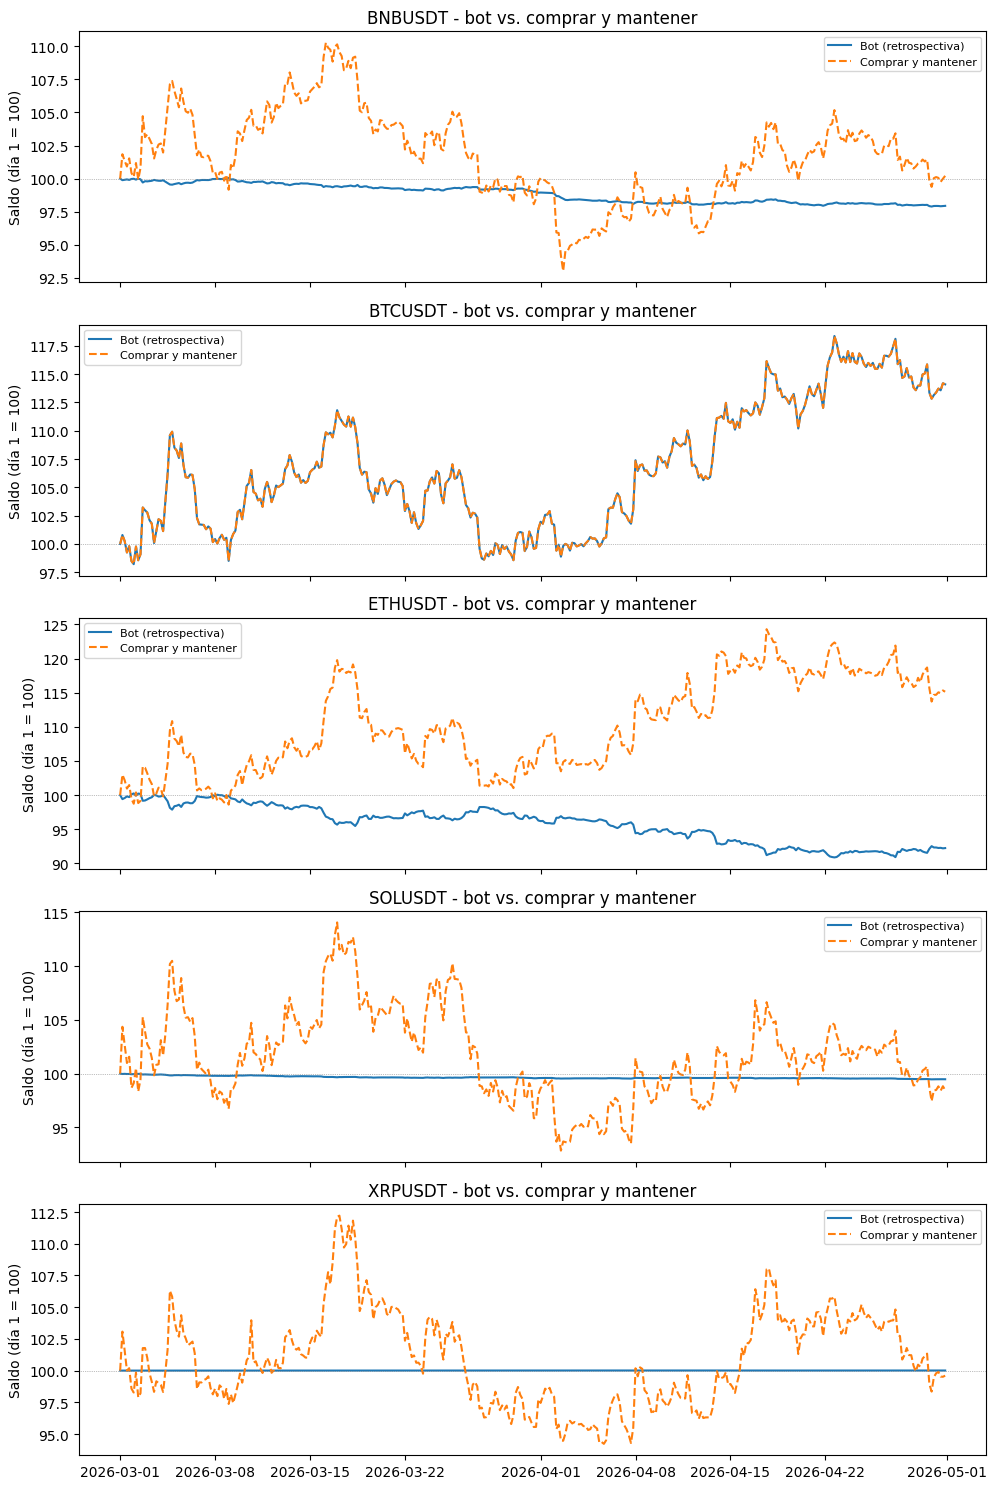

In [41]:
import matplotlib.pyplot as plt

if not events_by_symbol:
    print(
        f'Sin datos para comparar bot vs B&H: no hay subdirectorios con events.jsonl bajo {RUN_ROOT}. '
        f'Comprueba RUN_ID (actual: {RUN_ID!r}) y que la retrospectiva haya finalizado.'
    )
else:
    nrows = len(events_by_symbol)
    fig, axes = plt.subplots(nrows, 1, figsize=(10, 3 * nrows), sharex=True)
    if nrows == 1:
        axes = [axes]
    for ax, (sym, df) in zip(axes, events_by_symbol.items()):
        if df.empty or 'close_price' not in df.columns:
            ax.set_title(f'{sym} (sin eventos o sin close_price)')
            continue
        saldo_bot = equity_series(df)
        closes = pd.to_numeric(df['close_price'], errors='coerce').dropna()
        if closes.empty or saldo_bot.empty:
            ax.set_title(f'{sym} (sin saldo / precios)')
            continue
        initial_cash = initial_cash_by_symbol.get(sym, 10000.0)
        units = float(initial_cash) / float(closes.iloc[0])
        idx_bot = saldo_indice_100(saldo_bot)
        idx_bnh = saldo_indice_100(closes * units)
        ax.plot(idx_bot.index, idx_bot.values, label='Bot (retrospectiva)')
        ax.plot(
            idx_bnh.index, idx_bnh.values,
            label='Comprar y mantener', linestyle='--', color='#ff7f0e',
        )
        ax.axhline(100.0, color='gray', lw=0.5, ls=':')
        ax.set_title(f'{sym} - bot vs. comprar y mantener')
        ax.set_ylabel('Saldo (día 1 = 100)')
        ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()


## 5. Comparación lado a lado: live vs. retrospectiva

Si `LIVE_RUN_ID` apunta a un replay determinista de la ventana live (p. ej. bajo `reports/paper_trading/retrospective/live_window_replay_*/`) con `events.jsonl` por símbolo, cargamos esos eventos y producimos una tabla única con las **mismas métricas** para ambos bloques (ventana corta live y retrospectiva post-freeze). Esto permite citar en la memoria del TFG la coherencia operativa de las dos validaciones fuera de muestra sin saltar entre notebooks.


In [42]:
live_metrics: pd.DataFrame | None = None
if LIVE_RUN_ROOT is not None and LIVE_RUN_ROOT.exists():
    live_dirs = sorted([
        p for p in LIVE_RUN_ROOT.iterdir()
        if p.is_dir() and (p / 'events.jsonl').exists()
    ])
    live_events = {p.name: load_events(p) for p in live_dirs}
    if live_events:
        live_metrics = pd.DataFrame(
            {sym: metrics_for(df) for sym, df in live_events.items()}
        ).T
        live_metrics.index.name = 'simbolo'
else:
    print(
        f'Comparativa live no disponible: LIVE_RUN_ROOT={LIVE_RUN_ROOT!r} '
        f'(exists={LIVE_RUN_ROOT.exists() if LIVE_RUN_ROOT else False}). '
        'Asigna LIVE_RUN_ID en la celda de setup si quieres la tabla lado a lado.'
    )


In [43]:
side_by_side = None
if live_metrics is not None and not live_metrics.empty:
    common_cols = [
        'n_eventos',
        'primera_decision_ts',
        'ultima_decision_ts',
        'retorno_total_pct',
        'sharpe_paper_anual_4h',
        'sortino_paper_anual_4h',
        'drawdown_max_paper',
        'indice_ulcer_paper',
        'tasa_aciertos',
        'pct_largo',
        'pct_corto',
        'pct_plano',
        'pct_bloqueo_riesgo',
        'pct_feature_degradada',
    ]
    rows = []
    for sym in sorted(set(metrics.index).union(live_metrics.index)):
        row = {'simbolo': sym}
        for col in common_cols:
            row[f'live_{col}'] = (
                live_metrics.loc[sym, col]
                if sym in live_metrics.index and col in live_metrics.columns else None
            )
            row[f'retrospectiva_{col}'] = (
                metrics.loc[sym, col]
                if sym in metrics.index and col in metrics.columns else None
            )
        rows.append(row)
    side_by_side = pd.DataFrame(rows).set_index('simbolo')
side_by_side


,live_n_eventos,retrospectiva_n_eventos,live_primera_decision_ts,retrospectiva_primera_decision_ts,live_ultima_decision_ts,retrospectiva_ultima_decision_ts,live_retorno_total_pct,retrospectiva_retorno_total_pct,live_sharpe_paper_anual_4h,retrospectiva_sharpe_paper_anual_4h,...,live_pct_largo,retrospectiva_pct_largo,live_pct_corto,retrospectiva_pct_corto,live_pct_plano,retrospectiva_pct_plano,live_pct_bloqueo_riesgo,retrospectiva_pct_bloqueo_riesgo,live_pct_feature_degradada,retrospectiva_pct_feature_degradada
simbolo,,,,,,,,,,,,,,,,,,,,,
BNBUSDT,43,366,2026-05-21T08:00:00+00:00,2026-03-01T00:00:00+00:00,2026-05-28T08:00:00+00:00,2026-04-30T20:00:00+00:00,-0.001288,-0.020541,-3.110523,-5.389923,...,0.953488,0.644809,0.046512,0.355191,0.0,0.0,0.0,0.0,0.0,0.0
BTCUSDT,43,366,2026-05-21T08:00:00+00:00,2026-03-01T00:00:00+00:00,2026-05-28T08:00:00+00:00,2026-04-30T20:00:00+00:00,-0.056385,0.140953,-10.066951,2.067161,...,1.000000,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ETHUSDT,43,366,2026-05-21T08:00:00+00:00,2026-03-01T00:00:00+00:00,2026-05-28T08:00:00+00:00,2026-04-30T20:00:00+00:00,0.009065,-0.077612,5.162177,-3.686494,...,0.139535,0.068306,0.860465,0.931694,0.0,0.0,0.0,0.0,0.0,0.0
SOLUSDT,43,366,2026-05-21T08:00:00+00:00,2026-03-01T00:00:00+00:00,2026-05-28T08:00:00+00:00,2026-04-30T20:00:00+00:00,0.000532,-0.005265,6.685868,-6.211325,...,0.767442,0.661202,0.232558,0.338798,0.0,0.0,0.0,0.0,0.0,0.0
XRPUSDT,43,366,2026-05-21T08:00:00+00:00,2026-03-01T00:00:00+00:00,2026-05-28T08:00:00+00:00,2026-04-30T20:00:00+00:00,0.000006,0.000071,2.132885,3.238956,...,0.046512,0.286885,0.953488,0.713115,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Conclusiones de la retrospectiva

- La retrospectiva post-freeze amplía el horizonte fuera de muestra del live y permite comprobar si los patrones observados en tiempo real se sostienen en una ventana más larga.
- La comparación frente a Buy & Hold debe leerse junto con `drawdown_max_*` e `indice_ulcer_*`: no basta con mejorar retorno, también importa hacerlo con un perfil de caídas defendible.
- Los símbolos con `fixed_control` (BNB, ETH, SOL) tienden a mostrar cambios discretos de posición, mientras que `vol_target` (BTC, XRP) añade rebalanceos de tamaño sin flip, visibles en el panel extra de exposición.
- Si `side_by_side` está disponible, la lectura conjunta live vs retrospectiva ayuda a valorar estabilidad operativa entre una ventana corta en tiempo real y una ventana más larga post-freeze.
- El valor metodológico del bloque es de validación complementaria y trazabilidad: reutiliza el stack congelado del live sin reentrenar ni reoptimizar, por lo que la evidencia sigue siendo defendible en el bloque Results del TFG.


## 7. Persistir el reporte de cierre

El JSON resultante es la evidencia central de la retrospectiva post-freeze que se citará en la memoria del TFG, junto al `paper_run_postmortem.json` del live.


In [44]:
report = {
    'run_id': RUN_ID,
    'run_root': str(RUN_ROOT),
    'run_kind': 'post_freeze_retrospective',
    'live_run_id_compared': LIVE_RUN_ID,
    'metrics_per_symbol': metrics.to_dict(orient='index'),
    'buy_and_hold_per_symbol': {
        sym: buy_and_hold_metrics(df, initial_cash=initial_cash_by_symbol.get(sym, 10000.0))
        for sym, df in events_by_symbol.items()
    },
    'paper_vs_buy_and_hold': paper_vs_bnh.to_dict(orient='index'),
    'live_vs_retrospective': (
        side_by_side.to_dict(orient='index') if side_by_side is not None else None
    ),
    'methodological_disclaimers': [
        'No se reentrena ni reoptimiza ningún modelo, threshold ni política de sizing en la retrospectiva.',
        'Causalidad por construcción: endTime=decision_ts en klines y end=decision_ts en build_features.',
        'No se invoca live ingest durante la retrospectiva (refresh_live_data_before_decision=False).',
        'La retrospectiva complementa al paper trading live; no lo sustituye.',
    ],
}
if not RUN_ROOT.exists():
    print(f'No se persiste el reporte: RUN_ROOT no existe ({RUN_ROOT}). Configura RUN_ID y vuelve a ejecutar.')
else:
    report_path = RUN_ROOT / 'retrospective_postmortem.json'
    report_path.write_text(json.dumps(report, indent=2, ensure_ascii=False, default=str), encoding='utf-8')
    print(f'Reporte guardado: {report_path}')


Reporte guardado: /app/reports/paper_trading/retrospective/retrospective_postfreeze_20260301_20260430_voltarget_spot_cap/retrospective_postmortem.json
